In [40]:
import numpy as np
import cvxpy as cp
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt

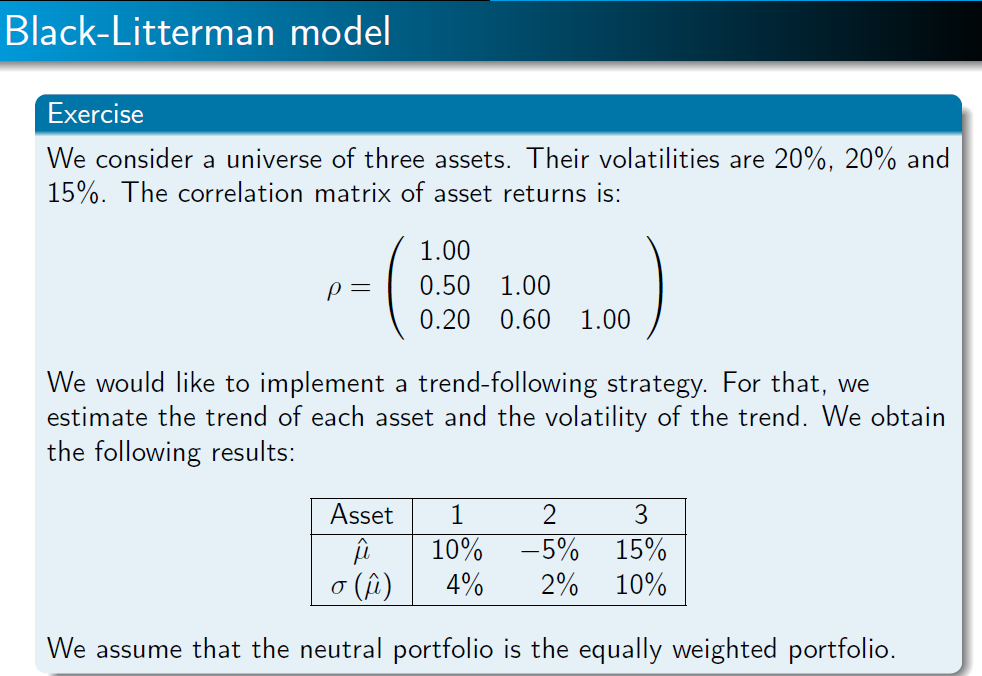

In [7]:
means = np.array([0.1, -0.05, 0.15])
mean_vols = np.array([0.04, 0.02, 0.1])
vols = np.array([0.2, 0.2, 0.15])
cor_mat = np.array([[1, 0.5, 0.2], [0.5, 1, 0.6], [0.2, 0.6, 1.0]])
cov_mat = np.diag(vols) @ cor_mat @ np.diag(vols).T
b = np.ones(len(means)) / len(means)

cov_mat

array([[0.04  , 0.02  , 0.006 ],
       [0.02  , 0.04  , 0.018 ],
       [0.006 , 0.018 , 0.0225]])

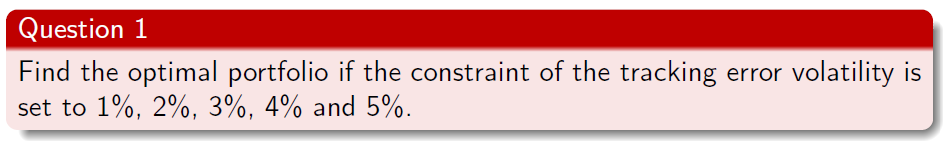

In [9]:
w = cp.Variable(len(means))
gamma = cp.Parameter(nonneg=True)
active_return = (w - b) @ means
tracking_error_var = cp.quad_form((w - b), cov_mat)
prob = cp.Problem(
    cp.Minimize(tracking_error_var - gamma * active_return),
    constraints=[cp.sum(w) == 1],
)

In [ ]:
def bisection(
    target: float, gamma_range: list[float, float], is_risk_target: bool = True
):
    def eval(tmp_gamma):
        nonlocal target
        gamma.value = tmp_gamma
        prob.solve()
        if is_risk_target:
            return np.sqrt(tracking_error_var.value) - target
        else:
            return active_return.value - target

    return optimize.bisect(eval, gamma_range[0], gamma_range[1])

# Compare our implementation with the results from prof.Thierry Roncalli's book.

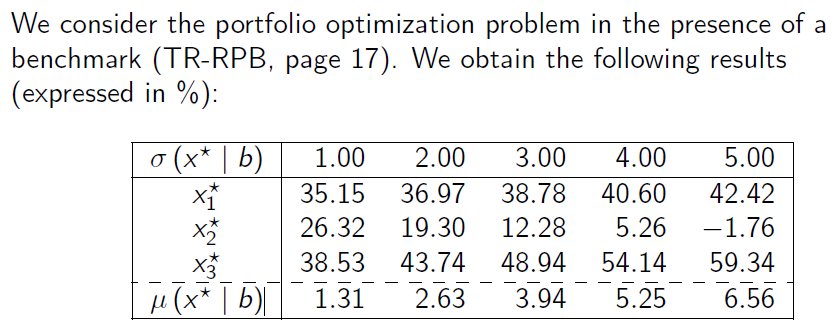

In [14]:
for target in [0.01, 0.02, 0.03, 0.04, 0.05]:
    optimal_gamma = bisection(
        target=target, gamma_range=[0.01, 100], is_risk_target=True
    )
    gamma.value = optimal_gamma
    prob.solve()
    print("Tracking error vol target:", target)
    print(
        "tracking error vol:",
        np.sqrt(tracking_error_var.value),
        "active return:",
        active_return.value,
    )
    print("Optimal weights:", w.value)
    print("----------------------------------")

Tracking error vol target: 0.01
tracking error vol: 0.00999999999921385 active return: 0.013126852516922055
Optimal weights: [0.35149868 0.26315773 0.38534359]
----------------------------------
Tracking error vol target: 0.02
tracking error vol: 0.01999999999957529 active return: 0.026253705035350124
Optimal weights: [0.36966402 0.19298214 0.43735384]
----------------------------------
Tracking error vol target: 0.03
tracking error vol: 0.030000000000105803 active return: 0.03938055755400066
Optimal weights: [0.38782937 0.12280654 0.48936409]
----------------------------------
Tracking error vol target: 0.04
tracking error vol: 0.04000000000045892 active return: 0.05250741007241809
Optimal weights: [0.40599472 0.05263094 0.54137435]
----------------------------------
Tracking error vol target: 0.05
tracking error vol: 0.050000000000986984 active return: 0.06563426259106529
Optimal weights: [ 0.42416006 -0.01754466  0.5933846 ]
----------------------------------


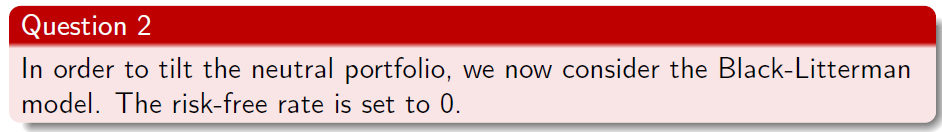
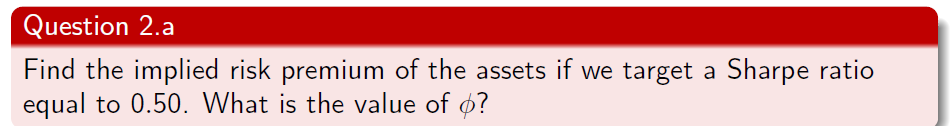

In [17]:
rf = 0
sr = 0.5
phi = sr / np.sqrt(b @ cov_mat @ b.T)
implied_mean = rf + sr * (cov_mat @ b.T) / np.sqrt(b @ cov_mat @ b.T)
print("Phi:", phi, "Implied return:", implied_mean)

Phi: 3.436716983117354 Implied return: [0.07560777 0.08935464 0.05326911]


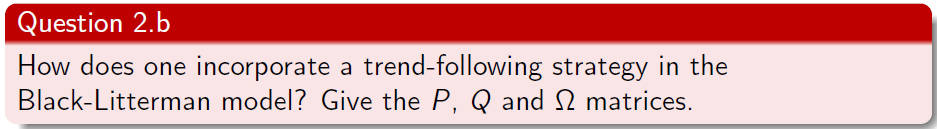

In [18]:
q = means  # Expected mean returns
p = np.eye(len(means))  # indicate absolute view of each asset
omega = np.diag(mean_vols) ** 2  # uncertainty of the estimated mean

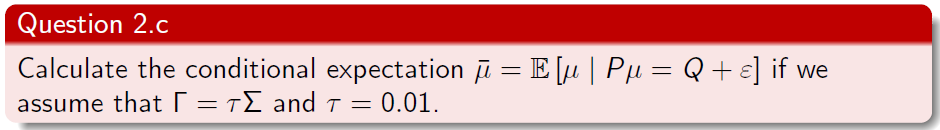
# Compared our implementation with the results from the book.
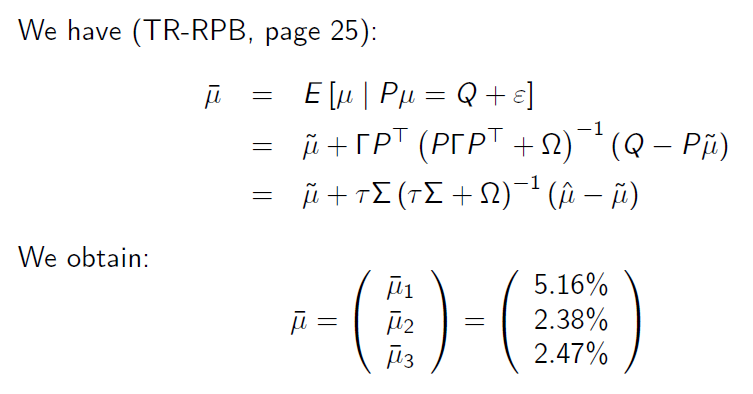

In [19]:
tau = 0.01
big_gamma = tau * cov_mat
posterior_means = implied_mean + tau * cov_mat @ np.linalg.inv(
    tau * cov_mat + omega
) @ (means - implied_mean)
posterior_means

array([0.05155454, 0.02383304, 0.02468064])

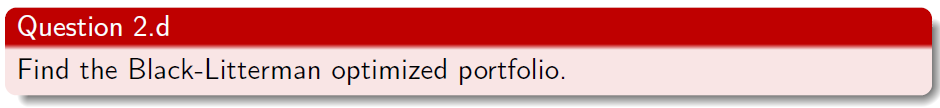
# Usually we can vary tau to customize the portfolio, but now tau is given as 0.01. Then, we compared against the results from the reference.
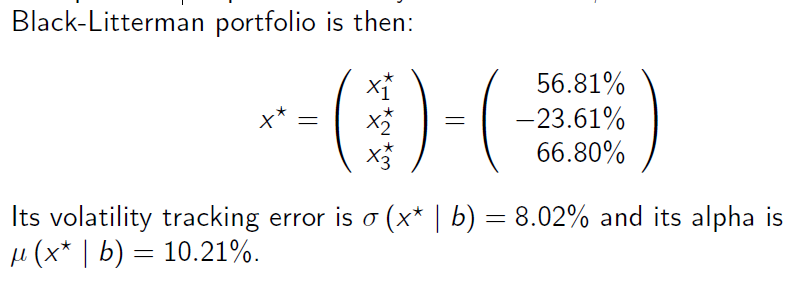

In [31]:
w = cp.Variable(len(means))
bl_gamma = cp.Parameter(nonneg=True)
bl_gamma.value = 1 / phi
bl_ret = (w) @ posterior_means
bl_var = cp.quad_form(w, cov_mat)
prob = cp.Problem(
    cp.Minimize(0.5 * bl_var - bl_gamma * bl_ret),
    constraints=[cp.sum(w) == 1],
)
prob.solve()
print(
    "Optimal tracking error vol:",
    np.sqrt(tracking_error_var.value),
    "Optimal active return:",
    active_return.value,
)
print("Optimal weights:", w.value)
print(
    "Optimal active return:",
    (w.value - b) @ means,
    "Optimal tracking error vol:",
    np.sqrt((w.value - b) @ cov_mat @ (w.value - b).T),
)

Optimal tracking error vol: 0.1367098301476765 Optimal active return: 0.04014658902446714
Optimal weights: [ 0.56805543 -0.23606251  0.66800708]
Optimal active return: 0.10214306362651854 Optimal tracking error vol: 0.08018002487677937


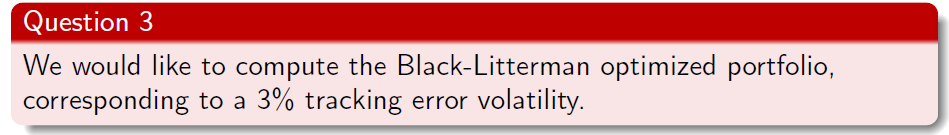
Now, we use bisection method again.

In [34]:
def bl_bisection(target: float, tau_range: list[float, float]):
    def eval(tau):
        nonlocal target
        big_gamma = tau * cov_mat
        posterior_means = implied_mean + tau * cov_mat @ np.linalg.inv(
            tau * cov_mat + omega
        ) @ (means - implied_mean)
        # Problem definition
        w = cp.Variable(len(means))
        bl_gamma = cp.Parameter(nonneg=True)
        bl_gamma.value = 1 / phi
        bl_ret = (w) @ posterior_means
        bl_var = cp.quad_form(w, cov_mat)
        prob = cp.Problem(
            cp.Minimize(0.5 * bl_var - bl_gamma * bl_ret),
            constraints=[cp.sum(w) == 1],
        )
        prob.solve()
        return np.sqrt((w.value - b) @ cov_mat @ (w.value - b).T) - target

    optimal_tau = optimize.bisect(eval, tau_range[0], tau_range[1])
    return optimal_tau


optimal_tau = bl_bisection(target=0.03, tau_range=[0.00001, 0.99999999])
print("Optimal Tau:", optimal_tau)

Optimal Tau: 0.002421166766400434


In [35]:
# solve the problem again with optimal_tau
big_gamma = optimal_tau * cov_mat
posterior_means = implied_mean + optimal_tau * cov_mat @ np.linalg.inv(
    optimal_tau * cov_mat + omega
) @ (means - implied_mean)
# Problem definition
w = cp.Variable(len(means))
bl_gamma = cp.Parameter(nonneg=True)
bl_gamma.value = 1 / phi
bl_ret = (w) @ posterior_means
bl_var = cp.quad_form(w, cov_mat)
prob = cp.Problem(
    cp.Minimize(0.5 * bl_var - bl_gamma * bl_ret),
    constraints=[cp.sum(w) == 1],
)
prob.solve()
print(
    "Optimal tracking error vol:",
    np.sqrt(tracking_error_var.value),
    "Optimal active return:",
    active_return.value,
)
print("Optimal weights:", w.value)
print(
    "Optimal active return:",
    (w.value - b) @ means,
    "Optimal tracking error vol:",
    np.sqrt((w.value - b) @ cov_mat @ (w.value - b).T),
)

Optimal tracking error vol: 0.1367098301476765 Optimal active return: 0.04014658902446714
Optimal weights: [0.41179948 0.11971588 0.46848464]
Optimal active return: 0.03880018376122569 Optimal tracking error vol: 0.02999999998364074


In [48]:
results = {"tau": [], "tracking error vol": [], "active return": []}

for tmp_tau in np.logspace(-6, -2.5, 100):
    # solve the problem again with tmp_tau
    big_gamma = tmp_tau * cov_mat
    posterior_means = implied_mean + tmp_tau * cov_mat @ np.linalg.inv(
        tmp_tau * cov_mat + omega
    ) @ (means - implied_mean)
    # Problem definition
    w = cp.Variable(len(means))
    bl_gamma = cp.Parameter(nonneg=True)
    bl_gamma.value = 1 / phi
    bl_ret = (w) @ posterior_means
    bl_var = cp.quad_form(w, cov_mat)
    prob = cp.Problem(
        cp.Minimize(0.5 * bl_var - bl_gamma * bl_ret),
        constraints=[cp.sum(w) == 1],
    )
    prob.solve()
    # print(
    #     "Optimal tracking error vol:",
    #     np.sqrt(tracking_error_var.value),
    #     "Optimal active return:",
    #     active_return.value,
    # )
    # print("Optimal weights:", w.value)
    # print(
    #     "Optimal active return:",
    #     (w.value - b) @ means,
    #     "Optimal tracking error vol:",
    #     np.sqrt((w.value - b) @ cov_mat @ (w.value - b).T),
    # )
    results["tau"].append(tmp_tau)
    results["active return"].append((w.value - b) @ means)
    results["tracking error vol"].append(
        np.sqrt((w.value - b) @ cov_mat @ (w.value - b).T)
    )
results = pd.DataFrame(results)
results

,tau,tracking error vol,active return
0,0.000001,0.000015,0.000020
1,0.000001,0.000017,0.000022
2,0.000001,0.000018,0.000023
3,0.000001,0.000020,0.000025
4,0.000001,0.000021,0.000027
...,...,...,...
95,0.002283,0.028594,0.036993
96,0.002477,0.030562,0.039523
97,0.002687,0.032634,0.042185
98,0.002915,0.034812,0.044979


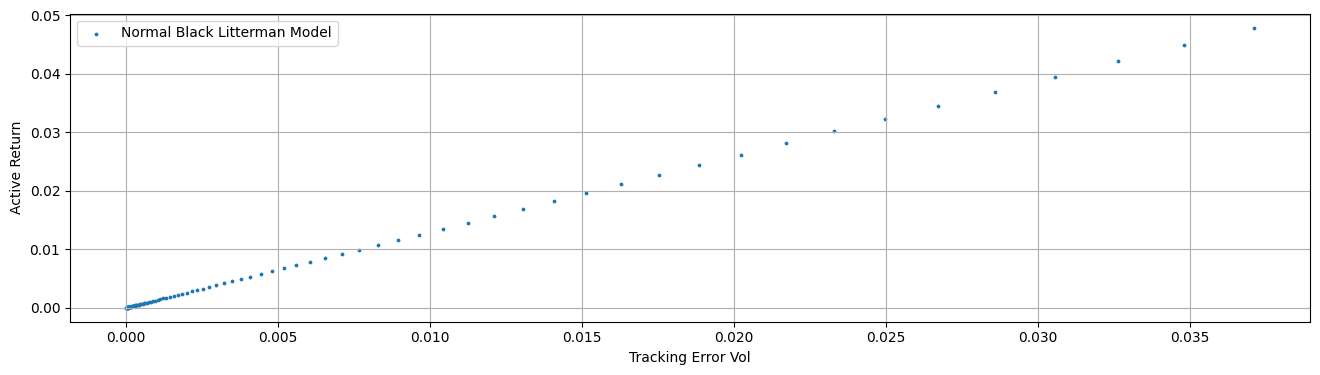

In [53]:
plt.figure(figsize=(16, 4))
plt.scatter(
    results["tracking error vol"],
    results["active return"],
    label="Normal Black Litterman Model",
    s=3,
)
plt.grid()
plt.legend()
plt.xlabel("Tracking Error Vol")
plt.ylabel("Active Return")
plt.show()